# Stage 6 — Business Experiment: Which 30% Should Receive Ads?

## Decision

Assume the company can advertise to only **30% of eligible users**. Which targeting policy produces the most incremental value?

The primary comparison uses the same visit objective as Stages 2–5:

1. **Random targeting:** select 30% without using user features.
2. **Response targeting:** select the 30% with the highest predicted visit probability.
3. **Causal targeting:** select the 30% with the highest predicted visit treatment effect.

A supplementary policy selects users with the highest predicted conversion probability. It answers a different objective and is reported separately rather than silently mixed into the visit comparison.

## What policy value means

For a policy that selects audience $S(X)\in\{0,1\}$, incremental visit value relative to treating nobody is

$$V(S)=E[S(X)(Y(1)-Y(0))].$$

At a fixed targeting share $q=30\%$, randomized assignment lets us estimate

$$\hat V(S)=q\left(\bar Y_{T=1,S=1}-\bar Y_{T=0,S=1}\right).$$

We report $1{,}000{,}000\times\hat V(S)$ as incremental events per one million eligible users. Every learned policy is trained outside the test set. Test outcomes are used only for final policy evaluation.

This is an offline policy experiment using a randomized holdout. It estimates intent-to-treat value under the experiment's population and treatment. It is not yet a prospective deployment experiment.

In [1]:
from pathlib import Path
import platform
import sys
import time
import warnings

import econml
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown
from scipy import stats
from sklearn import __version__ as sklearn_version
from sklearn.dummy import DummyClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from econml.dml import CausalForestDML

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='X does not have valid feature names.*')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

print('Python       :', platform.python_version())
print('Executable   :', Path(sys.executable).name)
print('NumPy        :', np.__version__)
print('pandas       :', pd.__version__)
print('scikit-learn:', sklearn_version)
print('LightGBM     :', lgb.__version__)
print('EconML       :', econml.__version__)

Python       : 3.10.19
Executable   : python
NumPy        : 2.2.6
pandas       : 2.3.2
scikit-learn: 1.7.1
LightGBM     : 4.6.0
EconML       : 0.17.0


## 1. Decision parameters

The 30% budget is the core business constraint. Economic inputs below are clearly labeled scenario assumptions because the dataset contains no media cost or monetary value. Change them to explore other cases.

Visit and conversion monetization are analyzed separately to avoid double-counting a conversion that is already downstream of a visit.

In [2]:
TARGET_SHARE = 0.30
ELIGIBLE_USERS = 1_000_000

# Illustrative economics; these are not observed in the Criteo data.
COST_PER_TARGETED_USER_USD = 0.01
VALUE_PER_INCREMENTAL_VISIT_USD = 1.00

assumptions = pd.Series({
    'target_share': TARGET_SHARE,
    'eligible_users': ELIGIBLE_USERS,
    'cost_per_targeted_user_usd': COST_PER_TARGETED_USER_USD,
    'value_per_incremental_visit_usd': VALUE_PER_INCREMENTAL_VISIT_USD,
}, name='value')
display(assumptions.to_frame())

,value
target_share,0.300000
eligible_users,"1,000,000.000000"
cost_per_targeted_user_usd,0.010000
value_per_incremental_visit_usd,1.000000


## 2. Reproduce the fixed sample and untouched holdout

The full file is streamed in chunks. We recreate the same approximately one-million-row sample and 60/20/20 split used in prior stages. All models use the same 400,000-row stratified training subset, validation controls early stopping, and the test set is reserved for final policy comparisons.

In [3]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'criteo-uplift-v2.1.csv').exists():
            return candidate
    raise FileNotFoundError('Could not find data/criteo-uplift-v2.1.csv.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / 'data' / 'criteo-uplift-v2.1.csv'
FEATURES = [f'f{i}' for i in range(12)]
KEEP_COLS = FEATURES + ['treatment', 'visit', 'conversion']
DTYPES = {**{c: 'float32' for c in FEATURES}, 'treatment': 'int8', 'visit': 'int8', 'conversion': 'int8'}
EXPECTED_ROWS = 13_979_592
SAMPLE_TARGET = 1_000_000
CHUNK_SIZE = 500_000
RANDOM_SEED = 42

start = time.perf_counter()
rng = np.random.default_rng(RANDOM_SEED)
parts = []
rows_scanned = 0
for chunk in pd.read_csv(DATA_PATH, usecols=KEEP_COLS, dtype=DTYPES, chunksize=CHUNK_SIZE):
    rows_scanned += len(chunk)
    keep = rng.random(len(chunk)) < SAMPLE_TARGET / EXPECTED_ROWS
    parts.append(chunk.loc[keep].copy())
df = pd.concat(parts, ignore_index=True)
print(f'Scanned {rows_scanned:,} rows in {time.perf_counter()-start:.1f} seconds.')
print(f'Modeling sample: {len(df):,} rows; memory {df.memory_usage(deep=True).sum()/1024**2:.1f} MiB.')

Scanned 13,979,592 rows in 12.0 seconds.
Modeling sample: 999,453 rows; memory 48.6 MiB.


In [4]:
strata = df['treatment'].astype(str) + '_' + df['visit'].astype(str)
train_df, temp_df = train_test_split(df, test_size=.40, random_state=RANDOM_SEED, stratify=strata)
temp_strata = temp_df['treatment'].astype(str) + '_' + temp_df['visit'].astype(str)
valid_df, test_df = train_test_split(temp_df, test_size=.50, random_state=RANDOM_SEED, stratify=temp_strata)
train_strata = train_df['treatment'].astype(str) + '_' + train_df['visit'].astype(str)
model_train, _ = train_test_split(train_df, train_size=400_000, random_state=RANDOM_SEED + 10, stratify=train_strata)

split_summary = pd.concat({
    name: frame.groupby('treatment')[['visit', 'conversion']].agg(['size', 'sum', 'mean'])
    for name, frame in [('training', model_train), ('validation', valid_df), ('test', test_df)]
}, names=['split', 'treatment'])
display(split_summary)
assert model_train.index.intersection(valid_df.index).empty
assert model_train.index.intersection(test_df.index).empty
assert valid_df.index.intersection(test_df.index).empty
assert not set(['treatment', 'visit', 'conversion', 'exposure']).intersection(FEATURES)
print('Split and leakage checks passed.')

visit                 conversion               
                        size    sum     mean       size   sum     mean
split      treatment                                                  
training   0           59831   2219 0.037088      59831   102 0.001705
           1          340169  16529 0.048591     340169  1023 0.003007
validation 0           29899   1109 0.037092      29899    60 0.002007
           1          169992   8260 0.048591     169992   536 0.003153
test       0           29900   1109 0.037090      29900    55 0.001839
           1          169991   8260 0.048591     169991   529 0.003112

Split and leakage checks passed.


## 3. Train the policy score models

The pooled visit-response model estimates who is likely to visit. The pooled conversion-response model estimates who is likely to convert. CausalForestDML estimates whose visit probability changes because of treatment.

Treatment is randomized, so the forest uses a constant-prior propensity model. All score models are trained without test outcomes.

In [5]:
def make_lgbm(seed, n_estimators=600):
    return lgb.LGBMClassifier(
        objective='binary', n_estimators=n_estimators, learning_rate=.05,
        num_leaves=31, min_child_samples=200, colsample_bytree=.9,
        reg_lambda=1.0, random_state=seed, n_jobs=-1, verbosity=-1,
    )

# Seeds match the corresponding Stage 4 models for cross-notebook reproducibility.
response_visit = make_lgbm(RANDOM_SEED + 33)
response_conversion = make_lgbm(RANDOM_SEED + 34)
response_fit_rows = []
for name, model, outcome in [
    ('Visit response', response_visit, 'visit'),
    ('Conversion response', response_conversion, 'conversion'),
]:
    start = time.perf_counter()
    model.fit(
        model_train[FEATURES], model_train[outcome],
        eval_set=[(valid_df[FEATURES], valid_df[outcome])],
        eval_metric='binary_logloss',
        callbacks=[lgb.early_stopping(40, verbose=False)],
    )
    response_fit_rows.append({
        'model': name, 'outcome': outcome,
        'positive_events': int(model_train[outcome].sum()),
        'best_iteration': model.best_iteration_,
        'fit_seconds': time.perf_counter() - start,
    })

X_train = model_train[FEATURES].to_numpy(dtype=np.float32)
X_valid = valid_df[FEATURES].to_numpy(dtype=np.float32)
X_test = test_df[FEATURES].to_numpy(dtype=np.float32)
causal_forest = CausalForestDML(
    model_y=make_lgbm(RANDOM_SEED + 20, n_estimators=180),
    model_t=DummyClassifier(strategy='prior'),
    discrete_outcome=True, discrete_treatment=True, categories=[0, 1], cv=2,
    n_estimators=200, criterion='mse', max_depth=15,
    min_samples_leaf=200, max_samples=.45, honest=True,
    inference=True, subforest_size=4, n_jobs=-1,
    random_state=RANDOM_SEED + 20,
)
start = time.perf_counter()
causal_forest.fit(
    model_train['visit'].to_numpy(dtype=np.int8),
    model_train['treatment'].to_numpy(dtype=np.int8),
    X=X_train, inference='auto',
)
forest_seconds = time.perf_counter() - start

scores_valid = {
    'Response: predicted visit': response_visit.predict_proba(valid_df[FEATURES])[:, 1],
    'Response: predicted conversion': response_conversion.predict_proba(valid_df[FEATURES])[:, 1],
    'Causal: predicted visit uplift': np.asarray(causal_forest.effect(X_valid)).reshape(-1),
}
scores_test = {
    'Response: predicted visit': response_visit.predict_proba(test_df[FEATURES])[:, 1],
    'Response: predicted conversion': response_conversion.predict_proba(test_df[FEATURES])[:, 1],
    'Causal: predicted visit uplift': np.asarray(causal_forest.effect(X_test)).reshape(-1),
}
fit_summary = pd.DataFrame(response_fit_rows).set_index('model')
fit_summary.loc['Causal forest', ['outcome', 'positive_events', 'best_iteration', 'fit_seconds']] = [
    'visit', int(model_train['visit'].sum()), 200, forest_seconds
]
display(fit_summary)

predictive_quality = pd.DataFrame([
    {'model': 'Visit response', 'ROC_AUC': roc_auc_score(test_df['visit'], scores_test['Response: predicted visit']),
     'PR_AUC': average_precision_score(test_df['visit'], scores_test['Response: predicted visit'])},
    {'model': 'Conversion response', 'ROC_AUC': roc_auc_score(test_df['conversion'], scores_test['Response: predicted conversion']),
     'PR_AUC': average_precision_score(test_df['conversion'], scores_test['Response: predicted conversion'])},
]).set_index('model')
display(predictive_quality)

,outcome,positive_events,best_iteration,fit_seconds
model,,,,
Visit response,visit,"18,748.000000",140.000000,1.888214
Conversion response,conversion,"1,125.000000",68.000000,1.114747
Causal forest,visit,"18,748.000000",200.000000,46.205418


,ROC_AUC,PR_AUC
model,,
Visit response,0.945108,0.508158
Conversion response,0.956704,0.239110


## 4. Lock the 30% policy audiences

Each learned policy selects exactly 30% of test users based only on its out-of-sample score. Random targeting is evaluated as the expected value of selecting 30% independently of features.

In [6]:
def top_mask(score, fraction):
    order = np.argsort(-np.asarray(score), kind='stable')
    selected_n = int(round(fraction * len(order)))
    mask = np.zeros(len(order), dtype=bool)
    mask[order[:selected_n]] = True
    return mask

policy_masks_test = {'Random targeting': None, **{name: top_mask(score, TARGET_SHARE) for name, score in scores_test.items()}}
policy_masks_valid = {'Random targeting': None, **{name: top_mask(score, TARGET_SHARE) for name, score in scores_valid.items()}}
PRIMARY_POLICIES = ['Random targeting', 'Response: predicted visit', 'Causal: predicted visit uplift']
ALL_POLICIES = PRIMARY_POLICIES + ['Response: predicted conversion']
audience_checks = pd.Series({name: TARGET_SHARE if mask is None else mask.mean() for name, mask in policy_masks_test.items()}, name='selected_share')
display(audience_checks.to_frame())
assert np.allclose(audience_checks, TARGET_SHARE, atol=1/len(test_df))

,selected_share
Random targeting,0.300000
Response: predicted visit,0.299998
Response: predicted conversion,0.299998
Causal: predicted visit uplift,0.299998


## 5. Randomized holdout policy evaluation

Within each selected audience, we estimate treated minus control outcome rates. Multiplying by 30% converts subgroup uplift into population-level incremental events.

Projected total events add the estimated incremental events to the all-control baseline. The incremental comparison is the more robust business quantity because every policy shares the same baseline.

In [7]:
def difference_in_means(y, t):
    treated, control = y[t == 1], y[t == 0]
    pt, pc = treated.mean(), control.mean()
    effect = pt - pc
    se = np.sqrt(pt * (1 - pt) / len(treated) + pc * (1 - pc) / len(control))
    return effect, se, len(treated), len(control)

def evaluate_policy_point(frame, mask, policy, outcome):
    y = frame[outcome].to_numpy()
    t = frame['treatment'].to_numpy()
    if mask is None:
        effect, se, treated_n, control_n = difference_in_means(y, t)
        selected_share = TARGET_SHARE
        selected_users = int(round(TARGET_SHARE * len(frame)))
    else:
        effect, se, treated_n, control_n = difference_in_means(y[mask], t[mask])
        selected_share = mask.mean()
        selected_users = int(mask.sum())
    incremental_rate = selected_share * effect
    no_treatment_rate = y[t == 0].mean()
    return {
        'policy': policy, 'outcome': outcome,
        'selected_share': selected_share, 'selected_users_in_test': selected_users,
        'selected_treated_n': treated_n, 'selected_control_n': control_n,
        'selected_subgroup_uplift': effect, 'uplift_se': se,
        'incremental_events_per_million': ELIGIBLE_USERS * incremental_rate,
        'projected_total_events_per_million': ELIGIBLE_USERS * (no_treatment_rate + incremental_rate),
    }

point_rows = []
for policy in ALL_POLICIES:
    for outcome in ['visit', 'conversion']:
        point_rows.append(evaluate_policy_point(test_df, policy_masks_test[policy], policy, outcome))
policy_points = pd.DataFrame(point_rows).set_index(['policy', 'outcome'])
business_table = policy_points['incremental_events_per_million'].unstack('outcome').rename(columns={
    'visit': 'incremental_visits_per_million',
    'conversion': 'incremental_conversions_per_million',
})
business_table['visit_value_vs_random'] = business_table['incremental_visits_per_million'] / business_table.loc['Random targeting', 'incremental_visits_per_million']
business_table['conversion_value_vs_random'] = business_table['incremental_conversions_per_million'] / business_table.loc['Random targeting', 'incremental_conversions_per_million']
display(business_table.loc[PRIMARY_POLICIES])
display(business_table.loc[['Response: predicted conversion']])

outcome,incremental_conversions_per_million,incremental_visits_per_million,visit_value_vs_random,conversion_value_vs_random
policy,,,,
Random targeting,381.739372,"3,450.152024",1.000000,1.000000
Response: predicted visit,"1,214.326345","10,007.861516",2.900702,3.181035
Causal: predicted visit uplift,"1,134.273423","10,062.964438",2.916673,2.971329


outcome,incremental_conversions_per_million,incremental_visits_per_million,visit_value_vs_random,conversion_value_vs_random
policy,,,,
Response: predicted conversion,"1,194.357327","10,079.397085",2.921436,3.128725


## 6. Paired bootstrap uncertainty

We resample the same test users for every policy so comparisons remain paired. Learned audience masks stay fixed. This quantifies holdout sampling uncertainty conditional on the trained models and fixed cutoff; it does not include model-retraining uncertainty.

In [8]:
def bootstrap_policy_values(frame, policy_masks, policies, outcomes, draws=300, seed=142):
    rng = np.random.default_rng(seed)
    n = len(frame)
    t = frame['treatment'].to_numpy()
    y_map = {outcome: frame[outcome].to_numpy() for outcome in outcomes}
    values = {(policy, outcome): np.empty(draws) for policy in policies for outcome in outcomes}
    for b in range(draws):
        idx = rng.integers(0, n, size=n)
        sampled_t = t[idx]
        for outcome in outcomes:
            sampled_y = y_map[outcome][idx]
            for policy in policies:
                mask = policy_masks[policy]
                selected = np.ones(n, dtype=bool) if mask is None else mask[idx]
                effect, _, _, _ = difference_in_means(sampled_y[selected], sampled_t[selected])
                values[(policy, outcome)][b] = ELIGIBLE_USERS * TARGET_SHARE * effect
    return values

N_BOOTSTRAP = 300
bootstrap_values = bootstrap_policy_values(test_df, policy_masks_test, ALL_POLICIES, ['visit', 'conversion'], N_BOOTSTRAP, RANDOM_SEED + 100)
bootstrap_rows = []
for policy in ALL_POLICIES:
    for outcome in ['visit', 'conversion']:
        draws = bootstrap_values[(policy, outcome)]
        bootstrap_rows.append({
            'policy': policy, 'outcome': outcome,
            'point_incremental_per_million': policy_points.loc[(policy, outcome), 'incremental_events_per_million'],
            'bootstrap_mean': draws.mean(), 'ci_95_low': np.quantile(draws, .025),
            'ci_95_high': np.quantile(draws, .975), 'probability_positive': np.mean(draws > 0),
        })
bootstrap_summary = pd.DataFrame(bootstrap_rows).set_index(['policy', 'outcome'])
display(bootstrap_summary.loc[PRIMARY_POLICIES])

comparison_rows = []
causal_name = 'Causal: predicted visit uplift'
for competitor in ['Random targeting', 'Response: predicted visit', 'Response: predicted conversion']:
    for outcome in ['visit', 'conversion']:
        diff = bootstrap_values[(causal_name, outcome)] - bootstrap_values[(competitor, outcome)]
        point_diff = policy_points.loc[(causal_name, outcome), 'incremental_events_per_million'] - policy_points.loc[(competitor, outcome), 'incremental_events_per_million']
        comparison_rows.append({
            'comparison': f'Causal minus {competitor}', 'outcome': outcome,
            'point_difference_per_million': point_diff,
            'ci_95_low': np.quantile(diff, .025), 'ci_95_high': np.quantile(diff, .975),
            'bootstrap_probability_causal_better': np.mean(diff > 0),
        })
comparison_table = pd.DataFrame(comparison_rows).set_index(['comparison', 'outcome'])
display(comparison_table)

point_incremental_per_million  \
policy                         outcome                                     
Random targeting               visit                        3,450.152024   
                               conversion                     381.739372   
Response: predicted visit      visit                       10,007.861516   
                               conversion                   1,214.326345   
Causal: predicted visit uplift visit                       10,062.964438   
                               conversion                   1,134.273423   

                                           bootstrap_mean    ci_95_low  \
policy                         outcome                                   
Random targeting               visit         3,452.021130 2,654.768107   
                               conversion      366.714181   211.025026   
Response: predicted visit      visit        10,057.093584 7,601.012144   
                               conversion    1,167.614113   649.532499   
Causal: predicted visit uplift visit        10,070.581650 7,780.188627   
                               conversion    1,080.782125   540.675725   

                                             ci_95_high  probability_positive  
policy                         outcome                                         
Random targeting               visit       4,151.867402              1.000000  
                               conversion    531.204753              1.000000  
Response: predicted visit      visit      12,376.559029              1.000000  
                               conversion  1,723.536276              1.000000  
Causal: predicted visit uplift visit      12,025.108438              1.000000  
                               conversion  1,590.283100              1.000000

point_difference_per_million  \
comparison                                  outcome                                    
Causal minus Random targeting               visit                       6,612.812415   
                                            conversion                    752.534052   
Causal minus Response: predicted visit      visit                          55.102923   
                                            conversion                    -80.052921   
Causal minus Response: predicted conversion visit                         -16.432647   
                                            conversion                    -60.083904   

                                                           ci_95_low  \
comparison                                  outcome                    
Causal minus Random targeting               visit       4,832.518625   
                                            conversion    342.443294   
Causal minus Response: predicted visit      visit      -1,042.961610   
                                            conversion   -236.987710   
Causal minus Response: predicted conversion visit      -1,239.492979   
                                            conversion   -229.328970   

                                                         ci_95_high  \
comparison                                  outcome                   
Causal minus Random targeting               visit      8,042.236402   
                                            conversion 1,078.972446   
Causal minus Response: predicted visit      visit      1,171.502163   
                                            conversion    83.266522   
Causal minus Response: predicted conversion visit      1,182.031221   
                                            conversion    93.676548   

                                                        bootstrap_probability_causal_better  
comparison                                  outcome                                          
Causal minus Random targeting               visit                                  1.000000  
                                            conversion                             1.000000  
Causal minus Response: predicted visit      visit                                  0.506667  
                                            conversion                             0.170000  
Causal minus Response: predicted conversion visit                                  0.460000  
                                            conversion                             0.246667

## 7. Audience overlap explains close policy values

Policy value depends on users for whom rankings disagree. If response and causal policies select mostly the same audience, a strong top-group effect does not imply a large difference between policies.

The table evaluates users selected by both policies, only by causal uplift, only by response probability, and by neither.

,value
causal_top30_users,"59,967.000000"
response_top30_users,"59,967.000000"
selected_by_both,"48,021.000000"
share_of_causal_audience_also_response,0.800790
Jaccard_similarity,0.667765
causal_only_users,"11,946.000000"
response_only_users,"11,946.000000"


,share,users,treated_n,control_n,observed_visit_uplift,se,ci_95_low,ci_95_high
segment,,,,,,,,
Selected by both,0.240236,48021,41176,6845,0.039666,0.004322,0.031195,0.048137
Causal only,0.059763,11946,10193,1753,0.005621,0.001790,0.002114,0.009129
Response only,0.059763,11946,10007,1939,0.008571,0.008353,-0.007801,0.024943
Selected by neither,0.640239,127978,108615,19363,0.000369,0.000317,-0.000253,0.000991


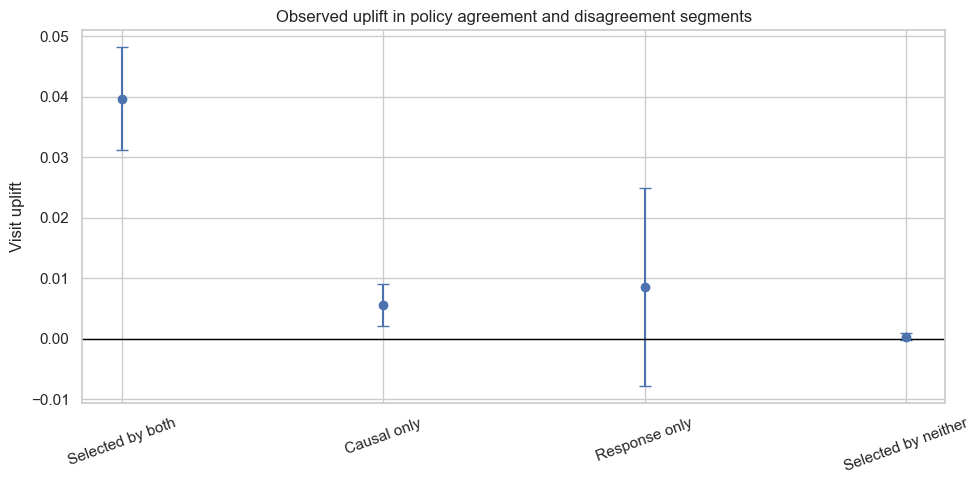

In [9]:
causal_mask = policy_masks_test['Causal: predicted visit uplift']
response_mask = policy_masks_test['Response: predicted visit']
intersection = causal_mask & response_mask
union = causal_mask | response_mask
overlap_summary = pd.Series({
    'causal_top30_users': causal_mask.sum(), 'response_top30_users': response_mask.sum(),
    'selected_by_both': intersection.sum(),
    'share_of_causal_audience_also_response': intersection.sum() / causal_mask.sum(),
    'Jaccard_similarity': intersection.sum() / union.sum(),
    'causal_only_users': (causal_mask & ~response_mask).sum(),
    'response_only_users': (response_mask & ~causal_mask).sum(),
}, name='value')
display(overlap_summary.to_frame())

disagreement_masks = {
    'Selected by both': causal_mask & response_mask,
    'Causal only': causal_mask & ~response_mask,
    'Response only': response_mask & ~causal_mask,
    'Selected by neither': ~causal_mask & ~response_mask,
}
disagreement_rows = []
for segment, mask in disagreement_masks.items():
    effect, se, treated_n, control_n = difference_in_means(test_df.loc[mask, 'visit'].to_numpy(), test_df.loc[mask, 'treatment'].to_numpy())
    disagreement_rows.append({
        'segment': segment, 'share': mask.mean(), 'users': int(mask.sum()),
        'treated_n': treated_n, 'control_n': control_n,
        'observed_visit_uplift': effect, 'se': se,
        'ci_95_low': effect - 1.96 * se, 'ci_95_high': effect + 1.96 * se,
    })
disagreement_table = pd.DataFrame(disagreement_rows).set_index('segment')
display(disagreement_table)
discordant_difference = disagreement_table.loc['Causal only', 'observed_visit_uplift'] - disagreement_table.loc['Response only', 'observed_visit_uplift']
discordant_se = np.sqrt(disagreement_table.loc['Causal only', 'se']**2 + disagreement_table.loc['Response only', 'se']**2)
discordant_p = 2 * stats.norm.sf(abs(discordant_difference / discordant_se))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(disagreement_table))
ax.errorbar(x, disagreement_table['observed_visit_uplift'],
            yerr=np.vstack([disagreement_table['observed_visit_uplift']-disagreement_table['ci_95_low'], disagreement_table['ci_95_high']-disagreement_table['observed_visit_uplift']]),
            fmt='o', capsize=4)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x, disagreement_table.index, rotation=20)
ax.set(title='Observed uplift in policy agreement and disagreement segments', ylabel='Visit uplift')
plt.tight_layout()
plt.show()

## 8. Translate effects into economics

$$\text{Net value}=\text{incremental visits}\times\text{value per visit}-\text{targeted users}\times\text{cost per user}.$$

At the same 30% budget, every policy has the same media cost. The conversion break-even column is a separate monetization case; do not add visit and conversion values unless they represent distinct, non-overlapping value.

,targeted_users_per_million,media_cost_usd,incremental_visits,visit_value_usd,net_visit_value_usd,net_visit_value_ci_95_low_usd,net_visit_value_ci_95_high_usd,visit_ROI,break_even_value_per_visit_usd,incremental_conversions,break_even_value_per_conversion_usd
policy,,,,,,,,,,,
Random targeting,"300,000.000000","3,000.000000","3,450.152024","3,450.152024",450.152024,-345.231893,"1,151.867402",0.150051,0.869527,381.739372,7.858765
Response: predicted visit,"300,000.000000","3,000.000000","10,007.861516","10,007.861516","7,007.861516","4,601.012144","9,376.559029",2.335954,0.299764,"1,214.326345",2.470506
Causal: predicted visit uplift,"300,000.000000","3,000.000000","10,062.964438","10,062.964438","7,062.964438","4,780.188627","9,025.108438",2.354321,0.298123,"1,134.273423",2.644865


,targeted_users_per_million,media_cost_usd,incremental_visits,visit_value_usd,net_visit_value_usd,net_visit_value_ci_95_low_usd,net_visit_value_ci_95_high_usd,visit_ROI,break_even_value_per_visit_usd,incremental_conversions,break_even_value_per_conversion_usd
policy,,,,,,,,,,,
Response: predicted conversion,"300,000.000000","3,000.000000","10,079.397085","10,079.397085","7,079.397085","4,570.588290","9,386.183811",2.359799,0.297637,"1,194.357327",2.511811


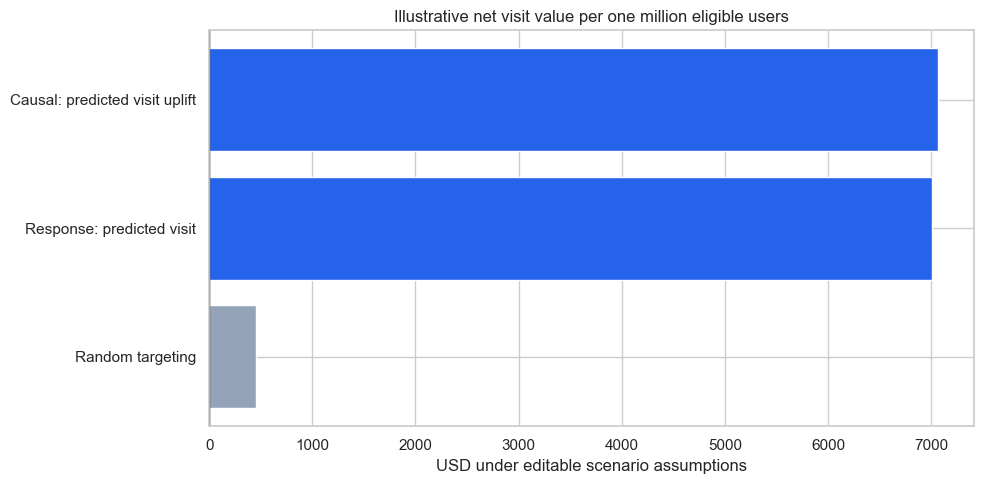

In [10]:
targeted_users = ELIGIBLE_USERS * TARGET_SHARE
media_cost = targeted_users * COST_PER_TARGETED_USER_USD
economic_rows = []
for policy in ALL_POLICIES:
    incremental_visits = policy_points.loc[(policy, 'visit'), 'incremental_events_per_million']
    incremental_conversions = policy_points.loc[(policy, 'conversion'), 'incremental_events_per_million']
    visit_revenue = incremental_visits * VALUE_PER_INCREMENTAL_VISIT_USD
    economic_rows.append({
        'policy': policy, 'targeted_users_per_million': targeted_users,
        'media_cost_usd': media_cost, 'incremental_visits': incremental_visits,
        'visit_value_usd': visit_revenue, 'net_visit_value_usd': visit_revenue - media_cost,
        'net_visit_value_ci_95_low_usd': bootstrap_summary.loc[(policy, 'visit'), 'ci_95_low'] * VALUE_PER_INCREMENTAL_VISIT_USD - media_cost,
        'net_visit_value_ci_95_high_usd': bootstrap_summary.loc[(policy, 'visit'), 'ci_95_high'] * VALUE_PER_INCREMENTAL_VISIT_USD - media_cost,
        'visit_ROI': (visit_revenue - media_cost) / media_cost,
        'break_even_value_per_visit_usd': media_cost / incremental_visits if incremental_visits > 0 else np.inf,
        'incremental_conversions': incremental_conversions,
        'break_even_value_per_conversion_usd': media_cost / incremental_conversions if incremental_conversions > 0 else np.inf,
    })
economics = pd.DataFrame(economic_rows).set_index('policy')
display(economics.loc[PRIMARY_POLICIES])
display(economics.loc[['Response: predicted conversion']])

fig, ax = plt.subplots(figsize=(10, 5))
plot_economics = economics.loc[PRIMARY_POLICIES].sort_values('net_visit_value_usd')
colors = ['#94a3b8' if name == 'Random targeting' else '#2563eb' for name in plot_economics.index]
ax.barh(plot_economics.index, plot_economics['net_visit_value_usd'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set(title='Illustrative net visit value per one million eligible users', xlabel='USD under editable scenario assumptions')
plt.tight_layout()
plt.show()

## 9. Budget sensitivity and validation-selected threshold

The fixed 30% result answers the stated decision. We also calculate value from 5% to 100%. Validation selects the share that maximizes illustrative net visit value; the locked share is then evaluated on test.

,validation_selected_share,validation_net_value_usd,test_incremental_visits_per_million,test_net_value_usd
policy,,,,
Random targeting,1.000000,"1,498.980384","11,500.506745","1,500.506745"
Response: predicted visit,0.250000,"6,797.504699","9,733.944370","7,233.944370"
Causal: predicted visit uplift,0.200000,"6,204.793363","9,593.013351","7,593.013351"


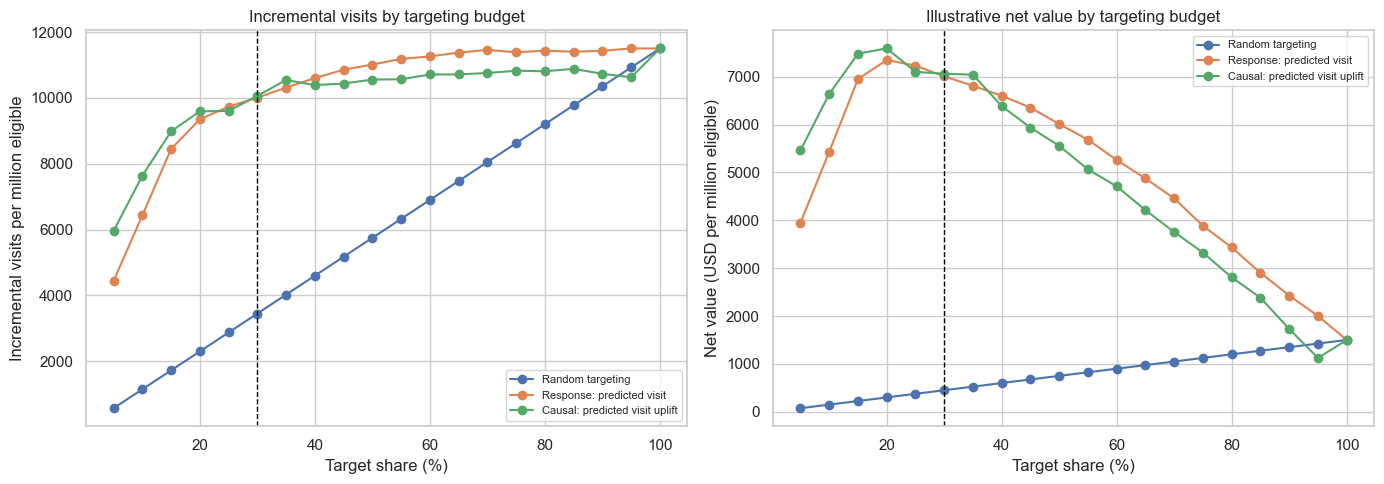

In [11]:
def policy_value_at_fraction(frame, score, fraction, outcome='visit'):
    y = frame[outcome].to_numpy()
    t = frame['treatment'].to_numpy()
    if score is None:
        effect, _, _, _ = difference_in_means(y, t)
    else:
        selected = top_mask(score, fraction)
        effect, _, _, _ = difference_in_means(y[selected], t[selected])
    return fraction * effect

fractions = np.arange(.05, 1.001, .05)
curve_rows = []
for split_name, frame, score_dict in [('validation', valid_df, scores_valid), ('test', test_df, scores_test)]:
    for policy in PRIMARY_POLICIES:
        score = None if policy == 'Random targeting' else score_dict[policy]
        for fraction in fractions:
            incremental_rate = policy_value_at_fraction(frame, score, fraction)
            incremental_visits = ELIGIBLE_USERS * incremental_rate
            net_value = incremental_visits * VALUE_PER_INCREMENTAL_VISIT_USD - ELIGIBLE_USERS * fraction * COST_PER_TARGETED_USER_USD
            curve_rows.append({'split': split_name, 'policy': policy, 'target_share': fraction,
                               'incremental_visits_per_million': incremental_visits, 'net_visit_value_usd': net_value})
budget_curves = pd.DataFrame(curve_rows)

locked_rows = []
for policy in PRIMARY_POLICIES:
    validation_part = budget_curves.loc[budget_curves['split'].eq('validation') & budget_curves['policy'].eq(policy)]
    best = validation_part.loc[validation_part['net_visit_value_usd'].idxmax()]
    test_locked = budget_curves.loc[
        budget_curves['split'].eq('test') & budget_curves['policy'].eq(policy) & np.isclose(budget_curves['target_share'], best['target_share'])
    ].iloc[0]
    locked_rows.append({'policy': policy, 'validation_selected_share': best['target_share'],
                        'validation_net_value_usd': best['net_visit_value_usd'],
                        'test_incremental_visits_per_million': test_locked['incremental_visits_per_million'],
                        'test_net_value_usd': test_locked['net_visit_value_usd']})
locked_budget_results = pd.DataFrame(locked_rows).set_index('policy')
display(locked_budget_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for policy in PRIMARY_POLICIES:
    part = budget_curves.loc[budget_curves['split'].eq('test') & budget_curves['policy'].eq(policy)]
    axes[0].plot(100 * part['target_share'], part['incremental_visits_per_million'], marker='o', label=policy)
    axes[1].plot(100 * part['target_share'], part['net_visit_value_usd'], marker='o', label=policy)
for ax in axes:
    ax.axvline(30, color='black', linestyle='--', linewidth=1)
axes[0].set(title='Incremental visits by targeting budget', xlabel='Target share (%)', ylabel='Incremental visits per million eligible')
axes[1].set(title='Illustrative net value by targeting budget', xlabel='Target share (%)', ylabel='Net value (USD per million eligible)')
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 10. Design the prospective policy A/B experiment

Randomize eligible users to policy arms. Each arm targets exactly 30% using its assigned locked policy. Compare overall eligible-population outcomes by assigned arm. Pre-register the primary outcome, budget, analysis window, minimum detectable effect, and stopping rule; monitor delivery, spend, latency, complaints, and other guardrails.

The sample-size calculation treats offline point estimates as planning inputs. Production planning should use a business-relevant minimum detectable effect rather than assume a noisy observed difference will reproduce exactly.

In [12]:
def two_proportion_sample_size_per_arm(p1, p2, alpha=.05, power=.80):
    delta = abs(p1 - p2)
    if delta == 0:
        return np.inf
    p_bar = (p1 + p2) / 2
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_power = stats.norm.ppf(power)
    numerator = (z_alpha * np.sqrt(2 * p_bar * (1 - p_bar)) + z_power * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2
    return int(np.ceil(numerator / delta ** 2))

no_treatment_visit_rate = test_df.loc[test_df['treatment'].eq(0), 'visit'].mean()
policy_visit_rates = {policy: no_treatment_visit_rate + policy_points.loc[(policy, 'visit'), 'incremental_events_per_million'] / ELIGIBLE_USERS for policy in PRIMARY_POLICIES}
power_rows = []
for competitor in ['Random targeting', 'Response: predicted visit']:
    p_causal = policy_visit_rates['Causal: predicted visit uplift']
    p_competitor = policy_visit_rates[competitor]
    power_rows.append({'comparison': f'Causal versus {competitor}', 'planned_causal_rate': p_causal,
                       'planned_competitor_rate': p_competitor, 'absolute_difference': p_causal - p_competitor,
                       'sample_size_per_arm_80pct_power': two_proportion_sample_size_per_arm(p_causal, p_competitor)})
power_from_points = pd.DataFrame(power_rows).set_index('comparison')
display(power_from_points)

planning_baseline = np.mean(list(policy_visit_rates.values()))
mde_rows = []
for mde_pp in [.10, .25, .50, .75]:
    delta = mde_pp / 100
    mde_rows.append({'MDE_percentage_points': mde_pp, 'baseline_visit_rate': planning_baseline,
                     'sample_size_per_arm_80pct_power': two_proportion_sample_size_per_arm(planning_baseline, planning_baseline + delta)})
mde_table = pd.DataFrame(mde_rows).set_index('MDE_percentage_points')
display(mde_table)

,planned_causal_rate,planned_competitor_rate,absolute_difference,sample_size_per_arm_80pct_power
comparison,,,,
Causal versus Random targeting,0.047153,0.040540,0.006613,15049
Causal versus Response: predicted visit,0.047153,0.047098,0.000055,232157088


,baseline_visit_rate,sample_size_per_arm_80pct_power
MDE_percentage_points,,
0.100000,0.044931,680759
0.250000,0.044931,110632
0.500000,0.044931,28369
0.750000,0.044931,12923


## 11. Automatically generated decision memo

This cell converts the executed results into a recommendation while preserving uncertainty.

In [13]:
random_name = 'Random targeting'
response_name = 'Response: predicted visit'
causal_name = 'Causal: predicted visit uplift'
conversion_name = 'Response: predicted conversion'
causal_visit = bootstrap_summary.loc[(causal_name, 'visit')]
response_visit_result = bootstrap_summary.loc[(response_name, 'visit')]
random_visit = bootstrap_summary.loc[(random_name, 'visit')]
causal_conversion = bootstrap_summary.loc[(causal_name, 'conversion')]
conversion_response_result = bootstrap_summary.loc[(conversion_name, 'conversion')]
diff_response = comparison_table.loc[(f'Causal minus {response_name}', 'visit')]
diff_random = comparison_table.loc[(f'Causal minus {random_name}', 'visit')]
causal_only = disagreement_table.loc['Causal only']
response_only = disagreement_table.loc['Response only']
best_primary_point = business_table.loc[PRIMARY_POLICIES, 'incremental_visits_per_million'].idxmax()

display(Markdown(f'''### Recommendation at the fixed 30% budget

- **Random targeting:** **{random_visit.point_incremental_per_million:,.0f}** incremental visits per million eligible users (95% bootstrap CI **{random_visit.ci_95_low:,.0f} to {random_visit.ci_95_high:,.0f}**).
- **Visit-response targeting:** **{response_visit_result.point_incremental_per_million:,.0f}** incremental visits (95% CI **{response_visit_result.ci_95_low:,.0f} to {response_visit_result.ci_95_high:,.0f}**).
- **Causal-uplift targeting:** **{causal_visit.point_incremental_per_million:,.0f}** incremental visits (95% CI **{causal_visit.ci_95_low:,.0f} to {causal_visit.ci_95_high:,.0f}**), plus **{causal_conversion.point_incremental_per_million:,.0f}** incremental conversions (95% CI **{causal_conversion.ci_95_low:,.0f} to {causal_conversion.ci_95_high:,.0f}**).
- The highest visit point estimate is **{best_primary_point}**. Causal minus Random is **{diff_random.point_difference_per_million:,.0f}** visits per million (95% CI **{diff_random.ci_95_low:,.0f} to {diff_random.ci_95_high:,.0f}**, bootstrap probability Causal is better **{diff_random.bootstrap_probability_causal_better:.1%}**).
- Causal minus Visit response is only **{diff_response.point_difference_per_million:,.0f}** visits per million (95% CI **{diff_response.ci_95_low:,.0f} to {diff_response.ci_95_high:,.0f}**, probability Causal is better **{diff_response.bootstrap_probability_causal_better:.1%}**). This does not establish a reliable advantage between the learned policies.
- Their similarity is structurally understandable: **{overlap_summary['share_of_causal_audience_also_response']:.1%}** of the causal top-30 audience is also selected by response ranking. Causal-only minus Response-only uplift is **{discordant_difference:.3%}** (95% CI **{discordant_difference-1.96*discordant_se:.3%} to {discordant_difference+1.96*discordant_se:.3%}**, p = **{discordant_p:.3g}**), so the smaller disagreement groups do not establish which model ranks better.
- The conversion-response model has strong conversion ROC-AUC, but its policy produces **{conversion_response_result.point_incremental_per_million:,.0f}** incremental conversions per million (95% CI **{conversion_response_result.ci_95_low:,.0f} to {conversion_response_result.ci_95_high:,.0f}**). Predicting likely converters does not guarantee the largest incremental conversion effect.
- Under the illustrative assumptions, Causal targeting has net visit value **USD {economics.loc[causal_name, 'net_visit_value_usd']:,.0f}** (95% CI **USD {economics.loc[causal_name, 'net_visit_value_ci_95_low_usd']:,.0f} to USD {economics.loc[causal_name, 'net_visit_value_ci_95_high_usd']:,.0f}**) per million eligible users, compared with **USD {economics.loc[response_name, 'net_visit_value_usd']:,.0f}** for Visit response and **USD {economics.loc[random_name, 'net_visit_value_usd']:,.0f}** for Random.
- When budget is allowed to vary under those same assumptions, validation selects **{locked_budget_results.loc[causal_name, 'validation_selected_share']:.0%}** for Causal and **{locked_budget_results.loc[response_name, 'validation_selected_share']:.0%}** for Visit response. Their test net values at the locked budgets are **USD {locked_budget_results.loc[causal_name, 'test_net_value_usd']:,.0f}** and **USD {locked_budget_results.loc[response_name, 'test_net_value_usd']:,.0f}**, respectively. This sensitivity result does not replace the pre-specified 30% comparison.
- A prospective Causal-versus-Random experiment needs roughly **{power_from_points.loc['Causal versus Random targeting', 'sample_size_per_arm_80pct_power']:,.0f} users per arm** at the offline point difference. Reproducing the tiny Causal-versus-response difference would need about **{power_from_points.loc['Causal versus Response: predicted visit', 'sample_size_per_arm_80pct_power']:,.0f} per arm**, so the team should power for a meaningful business MDE rather than for this noisy 55-per-million estimate.

**Decision:** both learned policies strongly outperform Random at 30%. The offline evidence does not justify claiming that Causal is better than the strong response baseline at this budget. Given the tiny estimated difference and extreme head-to-head sample requirement, prefer the simpler policy unless Causal has another operational advantage, or run an experiment powered for a pre-defined practically meaningful MDE rather than for the observed point gap.
'''))

### Recommendation at the fixed 30% budget

- **Random targeting:** **3,450** incremental visits per million eligible users (95% bootstrap CI **2,655 to 4,152**).
- **Visit-response targeting:** **10,008** incremental visits (95% CI **7,601 to 12,377**).
- **Causal-uplift targeting:** **10,063** incremental visits (95% CI **7,780 to 12,025**), plus **1,134** incremental conversions (95% CI **541 to 1,590**).
- The highest visit point estimate is **Causal: predicted visit uplift**. Causal minus Random is **6,613** visits per million (95% CI **4,833 to 8,042**, bootstrap probability Causal is better **100.0%**).
- Causal minus Visit response is only **55** visits per million (95% CI **-1,043 to 1,172**, probability Causal is better **50.7%**). This does not establish a reliable advantage between the learned policies.
- Their similarity is structurally understandable: **80.1%** of the causal top-30 audience is also selected by response ranking. Causal-only minus Response-only uplift is **-0.295%** (95% CI **-1.969% to 1.379%**, p = **0.73**), so the smaller disagreement groups do not establish which model ranks better.
- The conversion-response model has strong conversion ROC-AUC, but its policy produces **1,194** incremental conversions per million (95% CI **630 to 1,710**). Predicting likely converters does not guarantee the largest incremental conversion effect.
- Under the illustrative assumptions, Causal targeting has net visit value **USD 7,063** (95% CI **USD 4,780 to USD 9,025**) per million eligible users, compared with **USD 7,008** for Visit response and **USD 450** for Random.
- When budget is allowed to vary under those same assumptions, validation selects **20%** for Causal and **25%** for Visit response. Their test net values at the locked budgets are **USD 7,593** and **USD 7,234**, respectively. This sensitivity result does not replace the pre-specified 30% comparison.
- A prospective Causal-versus-Random experiment needs roughly **15,049 users per arm** at the offline point difference. Reproducing the tiny Causal-versus-response difference would need about **232,157,088 per arm**, so the team should power for a meaningful business MDE rather than for this noisy 55-per-million estimate.

**Decision:** both learned policies strongly outperform Random at 30%. The offline evidence does not justify claiming that Causal is better than the strong response baseline at this budget. Given the tiny estimated difference and extreme head-to-head sample requirement, prefer the simpler policy unless Causal has another operational advantage, or run an experiment powered for a pre-defined practically meaningful MDE rather than for the observed point gap.


## 12. Decision notes

- Subgroup uplift estimates the effect among selected users. Multiplying it by the selected share expresses incremental events over the entire eligible population.
- Response targeting can perform well when high-response and high-uplift users overlap, but this is an empirical property that must be checked using randomized policy-value evaluation.
- The learned policies produce a large improvement over random selection, while their heavily overlapping audiences make the causal-versus-response difference much smaller and harder to measure.
- Conversion is reported as a secondary downstream outcome and guardrail; a visit-optimized policy is not assumed to be conversion-optimal.
- Deployment should consider paired uncertainty, economic significance, implementation cost, calibration, latency, and guardrails rather than selecting the largest point estimate automatically.

### Production experiment checklist

1. Freeze the model version, features, eligibility rules, and targeting threshold.
2. Randomize users to complete policy engines before policy selection.
3. Log assignment, eligibility, score, selection, delivery, spend, and outcomes.
4. Pre-register the primary outcome, minimum detectable effect, sample size, analysis window, and exclusions.
5. Analyze by assigned arm and report absolute effects, confidence intervals, and cost-adjusted value.
6. Monitor guardrails and repeat across campaigns or time periods before broad rollout.